In [123]:
import os
import glob
import sys
import getpass
import importlib
from tqdm import tqdm
from pathlib import Path

# user path:
usrname = getpass.getuser()
# add paths:
sys.path.append(f'/Users/{usrname}/Desktop/Projects')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/bimanual_wrist')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/Functional_Fusion')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/PcmPy')


import rsatoolbox as rsa
from rsatoolbox.io import spm as spm_io
import surfAnalysisPy as surf
import SUITPy as suit
import nibabel as nb
import nitools as nt
import PcmPy as pcm
import Functional_Fusion.atlas_map as am
import Functional_Fusion.reliability as rel

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import seaborn as sns

import scipy.stats as stats
import scipy
import scipy.io as sio
import numpy as np
import pandas as pd

import utils
importlib.reload(utils)

# SET PATHS:
baseDir = os.path.join('/Users', getpass.getuser(), 'Desktop', 'Projects', 'bimanual_wrist', 'data', 'fMRI')
bidsDir = 'BIDS'
anatomicalDir = 'anatomicals'
freesurferDir = 'surfaceFreesurfer'
surfacewbDir = 'surfaceWB' 
behavDir = 'behavioural'
regDir = 'ROI'
atlasDir = '/Volumes/diedrichsen_data$/data/Atlas_templates/fs_LR_32'
analysisDir = os.path.join(os.path.dirname(os.path.dirname(baseDir)), 'analysis')



### congruency vs interaction

we want to model the congruency vs bimanual interaction. the question is whether component estimates in an OLS will be biased when noise is added to the data.

#### make the components:

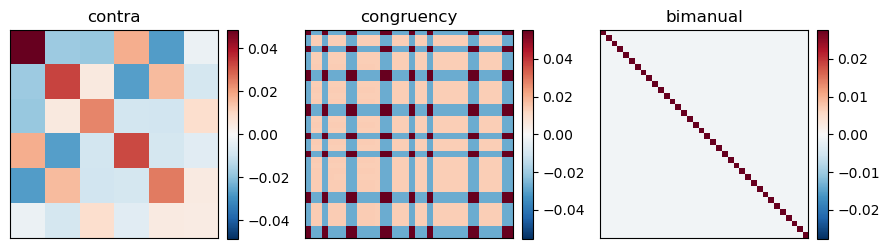

In [124]:
# contra:
labels = ['flx_flx',    'flx_flxup',   'flx_extup',   'flx_ext',   'flx_extdn',   'flx_flxdn',
          'flxup_flx',  'flxup_flxup', 'flxup_extup', 'flxup_ext', 'flxup_extdn', 'flxup_flxdn',
          'extup_flx',  'extup_flxup', 'extup_extup', 'extup_ext', 'extup_extdn', 'extup_flxdn',
          'ext_flx',    'ext_flxup',   'ext_extup',   'ext_ext',   'ext_extdn',   'ext_flxdn',
          'extdn_flx',  'extdn_flxup', 'extdn_extup', 'extdn_ext', 'extdn_extdn', 'extdn_flxdn',
          'flxdn_flx',  'flxdn_flxup', 'flxdn_extup', 'flxdn_ext', 'flxdn_extdn', 'flxdn_flxdn']   
F_contra = np.zeros((36,6))
cnd2idx = {'flx':0, 'flxup':1, 'extup':2, 'ext':3, 'extdn':4, 'flxdn':5}
for i in range(36):
    cond_pair = labels[i].split('_')
    cnd_contra = cond_pair[0]
    cnd_ipsi = cond_pair[1]
    idx_contra = cnd2idx[cnd_contra]
    idx_ipsi = cnd2idx[cnd_ipsi]
    F_contra[i, idx_contra] = 1
# center the features:
F_contra -= np.mean(F_contra, axis=0)

# load unimanual G matrix of all regions:
G_uni_df = pd.read_pickle(os.path.join(analysisDir, 'G_uni.pkl'))
# average across all subjects and regions:
G_all = np.concatenate(G_uni_df['G_hat'].tolist(), axis=0)  # (n_regions * N, 6, 6)
Guni = G_all.mean(axis=0)

# build fixed 36x36 model components from group-averaged unimanual G:
G_contra = F_contra @ Guni @ F_contra.T
G_contra = G_contra / np.trace(np.abs(G_contra))

# congruency model:
ncond = 36
cov_cong = np.zeros((ncond,ncond)) #np.eye(ncond)
idx_cong = [1,2,4,5, 6,9,10,11, 12,15,16,17, 19,20,22,23, 24,25,26,27, 30,31,32,33]
for i in range(len(idx_cong)):
    for j in range(len(idx_cong)):
        if i != j:
            cov_cong[idx_cong[i], idx_cong[j]] = 1
F_cong = np.zeros((ncond,1))
F_cong[idx_cong,0] = 1
cov_cong = F_cong @ F_cong.T
G_cong = pcm.centering(ncond) @ cov_cong @ pcm.centering(ncond) # incongruency model
G_cong = G_cong / np.trace(G_cong) # normalize the overall variance

# bimanual:
I = np.eye(ncond)
G_bimanual = pcm.centering(ncond) @ I @ I.T @ pcm.centering(ncond) # non-orthogonalized interaction
G_bimanual = G_bimanual / np.trace(G_bimanual) # normalize the overall variance

# orthogonalize the bimanual-specific model:
X = np.c_[G_contra, G_cong]
Io = I - X @ np.linalg.pinv(X) @ I
G_bimanual_orth = pcm.centering(ncond) @ Io @ Io.T @ pcm.centering(ncond) 
G_bimanual_orth = G_bimanual_orth / np.trace(G_bimanual_orth)

# visualize model components
components = [G_contra, G_cong, G_bimanual]
titles = ['contra', 'congruency', 'bimanual']
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for i, (G, title) in enumerate(zip(components, titles)):
    vmax = np.max(np.abs(G))
    vmin = -vmax
    im = ax[i].imshow(G, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    ax[i].set_title(title)
    ax[i].get_xaxis().set_visible(False)
    ax[i].get_yaxis().set_visible(False)
    plt.colorbar(im, ax=ax[i], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()



#### simulate data and run OLS

We generate data that only has contra and congruency components. We then fit the full model with contra+cong+bimanual to each subject. We then plot each component's weight and the distance associated with it.

- When theta = [2,0,0], meaning that both cong and bimanual exist equally:
    - the non-orthagonalized bimanual term is biased towards more positive. 
    - snr changes the variance of the estimates but not the expected value.
    - orthagonalizaion of the bimanual term to contra and congruency terms, changes the bias in the other direction. But will have a smaller bias overall

- When theta = [2,0,-20], meaning that both cong and bimanual exist equally:
    - the non-orthagonalized term is again biased towards positive.
    - orthagonalizaion of the bimanual term to contra and congruency terms, removes the bias and the estimate goes to 0.

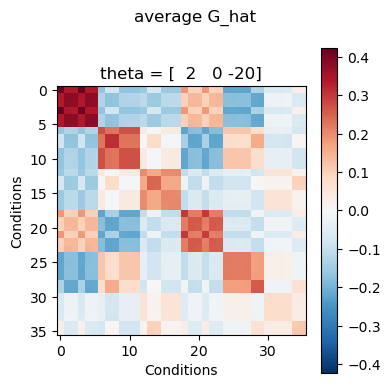

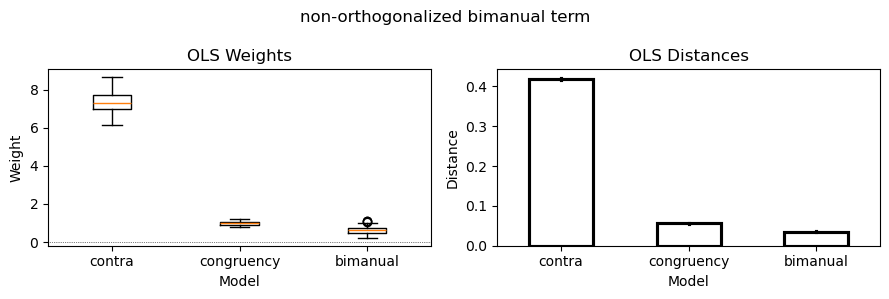

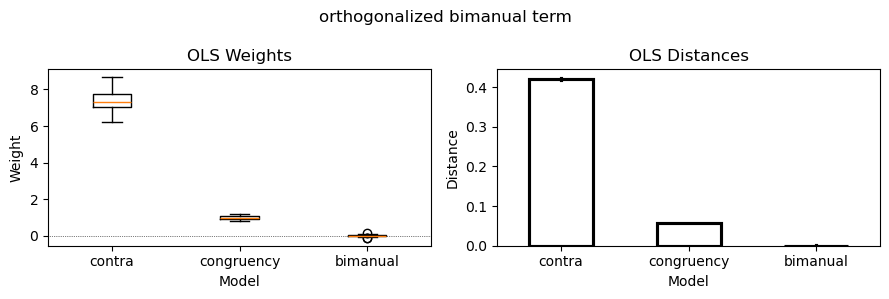

In [160]:
theta = np.array([2,0,-20])
Mtrue = pcm.ComponentModel('Gtrue', [G_contra, G_cong, G_bimanual])
nsim = 100
signal = [1]*nsim
ncond = 36
n_channel = 300

# generate data:
cond_vec, part_vec = pcm.sim.make_design(n_cond=36, n_part=10)
D = pcm.sim.make_dataset(model=Mtrue, \
    theta=theta,
    cond_vec=cond_vec,
    part_vec=part_vec,
    n_sim=nsim,
    n_channel=n_channel,
    signal=signal)

# data g matrix:
N = len(D)
G_hat = np.zeros((N, ncond, ncond))
for i in range(N):
    G_hat[i, :, :], _ = pcm.est_G_crossval(D[i].measurements,
                                            D[i].obs_descriptors['cond_vec'],
                                            D[i].obs_descriptors['part_vec'],
                                            X=pcm.matrix.indicator(D[i].obs_descriptors['part_vec']))

# visualize the average G:
G_mean = np.mean(G_hat, axis=0)
plt.figure(figsize=(4,4))
vmin = -np.max(np.abs(G_mean))
vmax = np.max(np.abs(G_mean))
plt.imshow(G_mean, cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title(f'theta = {theta}')
plt.suptitle('average G_hat')
plt.xlabel('Conditions')
plt.ylabel('Conditions')
plt.tight_layout()
plt.show()

# run OLS:
W = np.zeros((nsim, 3))
D_ols = np.zeros((nsim, 3))
# OLS:
X = np.vstack([
    G_contra.flatten(),
    G_cong.flatten(),
    G_bimanual.flatten(),
]).T
pinvX = np.linalg.pinv(X)
for i in range(nsim):
    W[i,:] = pinvX @ G_hat[i,:,:].flatten()

    # OLS variances:
    ols_contra = W[i,0] * np.trace(G_contra)/36
    ols_congruency = W[i,1] * np.trace(G_cong)/36
    ols_bimanual = W[i,2] * np.trace(G_bimanual)/36

    D_ols[i, 0] = 2/(36-1) * ols_contra*36
    D_ols[i, 1] = 2/(36-1) * ols_congruency*36
    D_ols[i, 2] = 2/(36-1) * ols_bimanual*36

# boxplot of the W and barplot of distances:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].boxplot(W)
ax[0].set_xticks(range(1, 4), ['contra', 'congruency', 'bimanual'])
ax[0].axhline(0, color='black', linewidth=0.5, linestyle=':')
ax[0].set_xlabel('Model')
ax[0].set_ylabel('Weight')
ax[0].set_title('OLS Weights')

df_d = pd.DataFrame(D_ols, columns=['contra', 'congruency', 'bimanual']).melt(
    var_name='component', value_name='d')
sns.barplot(data=df_d, x='component', y='d', ax=ax[1],
            color='k', fill=False, width=0.5, errorbar='se')
ax[1].axhline(0, color='black', linewidth=0.5, linestyle=':')
ax[1].set_xlabel('Model')
ax[1].set_ylabel('Distance')
ax[1].set_title('OLS Distances')

fig.suptitle('non-orthogonalized bimanual term')
plt.tight_layout()
plt.show()


# run OLS with orthagonalized bimanual term:
W = np.zeros((nsim, 3))
D_ols = np.zeros((nsim, 3))
# OLS:
X = np.vstack([
    G_contra.flatten(),
    G_cong.flatten(),
    G_bimanual_orth.flatten(),
]).T
pinvX = np.linalg.pinv(X)
for i in range(nsim):
    W[i,:] = pinvX @ G_hat[i,:,:].flatten()

    # OLS variances:
    ols_contra = W[i,0] * np.trace(G_contra)/36
    ols_congruency = W[i,1] * np.trace(G_cong)/36
    ols_bimanual = W[i,2] * np.trace(G_bimanual_orth)/36

    D_ols[i, 0] = 2/(36-1) * ols_contra*36
    D_ols[i, 1] = 2/(36-1) * ols_congruency*36
    D_ols[i, 2] = 2/(36-1) * ols_bimanual*36

# boxplot of the W and barplot of distances:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].boxplot(W)
ax[0].set_xticks(range(1, 4), ['contra', 'congruency', 'bimanual'])
ax[0].axhline(0, color='black', linewidth=0.5, linestyle=':')
ax[0].set_xlabel('Model')
ax[0].set_ylabel('Weight')
ax[0].set_title('OLS Weights')

df_d = pd.DataFrame(D_ols, columns=['contra', 'congruency', 'bimanual']).melt(
    var_name='component', value_name='d')
sns.barplot(data=df_d, x='component', y='d', ax=ax[1],
            color='k', fill=False, width=0.5, errorbar='se')
ax[1].axhline(0, color='black', linewidth=0.5, linestyle=':')
ax[1].set_xlabel('Model')
ax[1].set_ylabel('Distance')
ax[1].set_title('OLS Distances')

fig.suptitle('orthogonalized bimanual term')
plt.tight_layout()
plt.show()
